In [39]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [40]:
# Cálculo científico y vectorial para python
import numpy as np
import pandas as pd
# Libreria para graficos
import matplotlib.pyplot as plt

from tensorflow.keras.datasets import cifar10

# Modulo de optimizacion en scipy
from scipy import optimize

# le dice a matplotlib que incruste gráficos en el cuaderno
%matplotlib inline

CIFAR-10 es un conjunto de datos de imágenes RGB de 32×32 píxeles pertenecientes a 10 clases. El dataset contiene 60.000 imágenes, por lo que cumple con el requisito mínimo de 50.000 ejemplos establecido para este laboratorio.

En este trabajo se utilizan las 60.000 imágenes disponibles y posteriormente se realiza una división del 80% para entrenamiento y 20% para prueba.

Para aplicar regresión logística, las imágenes deben convertirse de su representación matricial a un vector de características. Cada imagen de CIFAR-10 tiene 32×32 píxeles y tres canales de color RGB, por lo que cada imagen queda representada mediante 3072 características.

Se utiliza Pandas para organizar las características y las etiquetas en un DataFrame, facilitando el procesamiento posterior de los datos.

In [41]:
from tensorflow.keras.datasets import cifar10

(X_train_original, y_train_original), (X_test_original, y_test_original) = cifar10.load_data()

# Unimos los datos originales para realizar nuestra propia división 80/20
X = np.concatenate([X_train_original, X_test_original], axis=0)
y = np.concatenate([y_train_original, y_test_original], axis=0).ravel()

print("Dataset completo:", X.shape)
print("Etiquetas:", y.shape)

Dataset completo: (60000, 32, 32, 3)
Etiquetas: (60000,)


In [42]:
import pandas as pd

# Convertimos cada imagen 32x32x3 en un vector de 3072 características
X_flat = X.reshape(X.shape[0], -1)

# Creamos un DataFrame para realizar el preprocesamiento con Pandas
df = pd.DataFrame(X_flat)

# Agregamos la etiqueta de cada imagen
df["label"] = y

print("Dimensiones del DataFrame:", df.shape)

Dimensiones del DataFrame: (60000, 3073)


In [43]:
# Configuración del dataset CIFAR-10

input_layer_size = 3072

# CIFAR-10 tiene 10 clases
num_labels = 10

print("Dimensión X entrenamiento:", X_train.shape)
print("Dimensión y entrenamiento:", y_train.shape)

print("Dimensión X prueba:", X_test.shape)
print("Dimensión y prueba:", y_test.shape)

Dimensión X entrenamiento: (50000, 3072)
Dimensión y entrenamiento: (50000,)
Dimensión X prueba: (10000, 3072)
Dimensión y prueba: (10000,)


In [45]:
X_entrenamiento = X_entrenamiento / 255.0
X_prueba = X_prueba / 255.0

print("Rango entrenamiento:", X_entrenamiento.min().min(), X_entrenamiento.max().max())
print("Rango prueba:", X_prueba.min().min(), X_prueba.max().max())


Rango entrenamiento: 0.0 0.00392156862745098
Rango prueba: 0.0 0.00392156862745098


In [61]:
# Uso de Pandas para inspección y preprocesamiento del dataset

# Convertimos cada imagen 32x32x3 en un vector de 3072 características
X_flat = X.values.reshape(X.shape[0], -1)

# Creamos el DataFrame con Pandas
df = pd.DataFrame(X_flat)

# Agregamos las etiquetas
df["label"] = y

print("Dimensiones del DataFrame:", df.shape)

from sklearn.model_selection import train_test_split

# Separamos características y etiquetas
X = df.drop("label", axis=1)
y = df["label"]

# División 80% entrenamiento y 20% prueba
X_entrenamiento, X_prueba, y_entrenamiento, y_prueba = train_test_split(

    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)
X_entrenamiento = X_entrenamiento / 255.0
X_prueba = X_prueba / 255.0

print("Entrenamiento:", X_entrenamiento.shape)
print("Prueba:", X_prueba.shape)

Dimensiones del DataFrame: (60000, 3073)
Entrenamiento: (48000, 3072)
Prueba: (12000, 3072)


Para validar correctamente el modelo, se divide el dataset completo utilizando el 80% de los ejemplos para entrenamiento y el 20% restante para prueba. La división se realiza antes del entrenamiento para garantizar que los ejemplos utilizados para evaluar el modelo no sean utilizados durante su aprendizaje.

Además, se utiliza una división estratificada para conservar una distribución equilibrada de las clases en ambos conjuntos.

In [62]:
# Verificar el balance de las clases

print("Cantidad de ejemplos por clase en entrenamiento:")
print(pd.Series(y_entrenamiento).value_counts().sort_index())

print("\nCantidad de ejemplos por clase en prueba:")
print(pd.Series(y_prueba).value_counts().sort_index())

Cantidad de ejemplos por clase en entrenamiento:
label
0    4800
1    4800
2    4800
3    4800
4    4800
5    4800
6    4800
7    4800
8    4800
9    4800
Name: count, dtype: int64

Cantidad de ejemplos por clase en prueba:
label
0    1200
1    1200
2    1200
3    1200
4    1200
5    1200
6    1200
7    1200
8    1200
9    1200
Name: count, dtype: int64


In [63]:
def sigmoid(z):
    """
    Calcula la sigmoide de z.
    """
    return 1.0 / (1.0 + np.exp(-z))

In [64]:
def calcularCosto(theta, X, y):
    # Inicializar algunos valores utiles
    m = y.size  # numero de ejemplos de entrenamiento

    J = 0
    h = sigmoid(X.dot(theta.T))
    J = (1 / m) * np.sum(-y.dot(np.log(h)) - (1 - y).dot(np.log(1 - h)))

    return J

In [65]:
def descensoGradiente(theta, X, y, alpha, num_iters):
    # Inicializa algunos valores
    m = y.shape[0] # numero de ejemplos de entrenamiento

    # realiza una copia de theta, el cual será acutalizada por el descenso por el gradiente
    theta = theta.copy()
    J_history = []

    for i in range(num_iters):
        h = sigmoid(X.dot(theta.T))
        theta = theta - (alpha / m) * (h - y).dot(X)

        J_history.append(calcularCosto(theta, X, y))
    return theta, J_history

In [66]:
def lrCostFunction(theta, X, y, lambda_):
#     alpha = 0.003
#     theta = theta.copy()
    # Inicializa algunos valores utiles
    m = y.size

    # convierte las etiquetas a valores enteros si son boleanos
    if y.dtype == bool:
        y = y.astype(int)

    J = 0
    grad = np.zeros(theta.shape)

    h = sigmoid(X.dot(theta.T))

    temp = theta
    temp[0] = 0

#     J = (1 / m) * np.sum(-y.dot(np.log(h)) - (1 - y).dot(np.log(1 - h)))
    J = (1 / m) * np.sum(-y.dot(np.log(h)) - (1 - y).dot(np.log(1 - h))) + (lambda_ / (2 * m)) * np.sum(np.square(temp))

    grad = (1 / m) * (h - y).dot(X)
#     theta = theta - (alpha / m) * (h - y).dot(X)
    grad = grad + (lambda_ / m) * temp

    return J, grad
#    return J, theta

In [67]:
def OneVsAll(X, y, num_labels, lambda_):
  alpha = 0.001
  num_iters = 100000

  m, n = X.shape
  all_theta = np.zeros((num_labels, n + 1))

  # Agrega unos a la matriz X
  X = np.concatenate([np.ones((m, 1)), X], axis=1)

  for c in np.arange(num_labels):
      initial_theta = np.zeros(n + 1)

      y_actual = np.where(y == c, 1, 0)

      theta, J_history = descensoGradiente(initial_theta, X, y_actual, alpha, num_iters)

      all_theta[c] = theta
      # Grafica la convergencia del costo
      pyplot.plot(np.arange(len(J_history)), J_history, lw=2)
      pyplot.xlabel('Numero de iteraciones')
      pyplot.ylabel('Costo J')

  return all_theta

In [68]:
def OneVsAllOM(X, y, num_labels, lambda_):
    """
    Entrena un clasificador de regresión logística para cada clase
    utilizando la estrategia One-vs-All.

    Retorna:
    - all_theta: parámetros aprendidos para cada clase
    - all_costs: historial del costo de cada clasificador
    """

    m, n = X.shape

    # Matriz donde se guardarán los parámetros de cada clase
    all_theta = np.zeros((num_labels, n + 1))

    # Agregar término de intercepto
    X = np.concatenate([np.ones((m, 1)), X], axis=1)

    # Guardaremos el costo de cada clasificador
    all_costs = []

    for c in np.arange(num_labels):

        print("Entrenando clasificador para la clase:", c)

        # Parámetros iniciales
        initial_theta = np.zeros(n + 1)

        # Lista para guardar el costo durante el entrenamiento
        cost_history = []

        # Función que registra el costo en cada iteración
        def callback(theta):
            cost, grad = lrCostFunction(
                theta,
                X,
                (y == c),
                lambda_
            )
            cost_history.append(cost)

        # Opciones del optimizador
        options = {
            'maxiter': 3
        }

        # Entrenamiento
        res = optimize.minimize(
            lrCostFunction,
            initial_theta,
            (X, (y == c), lambda_),
            jac=True,
            method='CG',
            callback=callback,
            options=options
        )

        # Guardar parámetros aprendidos
        all_theta[c] = res.x

        # Guardar historial del costo
        all_costs.append(cost_history)

    return all_theta, all_costs

In [69]:
lambda_ = 0.1

all_theta, all_costs = OneVsAllOM(
    X_entrenamiento,
    y_entrenamiento,
    num_labels,
    lambda_
)

print("Dimensión de all_theta:", all_theta.shape)

Entrenando clasificador para la clase: 0
Entrenando clasificador para la clase: 1
Entrenando clasificador para la clase: 2
Entrenando clasificador para la clase: 3
Entrenando clasificador para la clase: 4
Entrenando clasificador para la clase: 5
Entrenando clasificador para la clase: 6
Entrenando clasificador para la clase: 7
Entrenando clasificador para la clase: 8
Entrenando clasificador para la clase: 9
Dimensión de all_theta: (10, 3073)


In [70]:
print(all_theta)

[[-0.00972724 -0.00198475 -0.00112276 ... -0.00327683 -0.00255477
  -0.00081539]
 [-0.00415355 -0.00103036 -0.00126116 ... -0.00117932 -0.00121875
  -0.0006593 ]
 [-0.01561908 -0.00127728 -0.00088296 ... -0.00206514 -0.0011634
  -0.00300616]
 ...
 [-0.01585104  0.00292133  0.00361395 ...  0.00388147  0.00235017
  -0.00248141]
 [-0.01469751 -0.00059875  0.0014981  ... -0.01051041 -0.00757387
  -0.00274386]
 [-0.01203303  0.00533814  0.00626977 ... -0.00010183 -0.00064561
   0.00107402]]


<a id="section3"></a>
#### 1.4.1 Prediccion One-vs-all

Después de entrenar el clasificador de one-vs-all, se puede usarlo para predecir el dígito contenido en una imagen determinada. Para cada entrada, debe calcular la "probabilidad" de que pertenezca a cada clase utilizando los clasificadores de regresión logística entrenados. La función de predicción one-vs-all seleccionará la clase para la cual el clasificador de regresión logística correspondiente genera la probabilidad más alta y devolverá la etiqueta de clase (0, 1, ..., K-1) como la predicción para el ejemplo de entrada.

In [71]:
def predictOneVsAll(all_theta, X):
    """
    Devuelve un vector de predicciones para cada ejemplo en la matriz X.
    Tenga en cuenta que X contiene los ejemplos en filas.
    all_theta es una matriz donde la i-ésima fila es un vector theta de regresión logística entrenada para la i-ésima clase.
    Debe establecer p en un vector de valores de 0..K-1 (por ejemplo, p = [0, 2, 0, 1]
    predice clases 0, 2, 0, 1 para 4 ejemplos).

    Parametros
    ----------
    all_theta : array_like
        The trained parameters for logistic regression for each class.
        This is a matrix of shape (K x n+1) where K is number of classes
        and n is number of features without the bias.

    X : array_like
        Data points to predict their labels. This is a matrix of shape
        (m x n) where m is number of data points to predict, and n is number
        of features without the bias term. Note we add the bias term for X in
        this function.

    Devuelve
    -------
    p : array_like
        The predictions for each data point in X. This is a vector of shape (m, ).
    """

    m = X.shape[0];
    num_labels = all_theta.shape[0]

    p = np.zeros(m)

    # Add ones to the X data matrix
    X = np.concatenate([np.ones((m, 1)), X], axis=1)
    p = np.argmax(sigmoid(X.dot(all_theta.T)), axis = 1)

    return p

Una vez que haya terminado, se llama a la función `predictOneVsAll` usando el valor aprendido de $\theta$. Debería apreciarse que la precisión del conjunto de entrenamiento es de aproximadamente 95,1% (es decir, clasifica correctamente el 95,1% de los ejemplos del conjunto de entrenamiento).

In [72]:
pred_entrenamiento = predictOneVsAll(
    all_theta,
    X_entrenamiento
)

precision_entrenamiento = np.mean(
    pred_entrenamiento == y_entrenamiento
) * 100

print("Precisión sobre entrenamiento: {:.2f}%".format(
    precision_entrenamiento
))

Precisión sobre entrenamiento: 28.12%


In [73]:
pred_prueba = predictOneVsAll(
    all_theta,
    X_prueba
)

precision_prueba = np.mean(
    pred_prueba == y_prueba
) * 100

print("Precisión sobre prueba: {:.2f}%".format(
    precision_prueba
))

Precisión sobre prueba: 28.47%


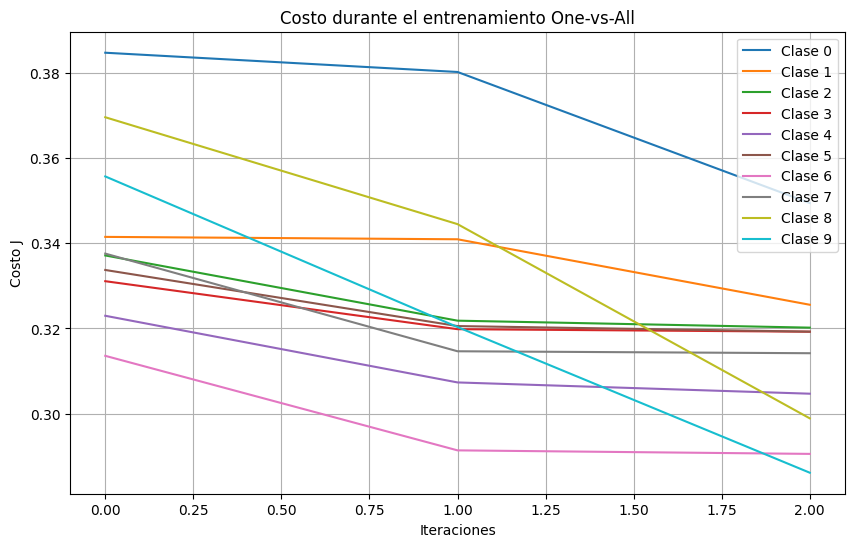

In [74]:
plt.figure(figsize=(10, 6))

for c in range(num_labels):
    plt.plot(
        all_costs[c],
        label="Clase " + str(c)
    )

plt.xlabel("Iteraciones")
plt.ylabel("Costo J")
plt.title("Costo durante el entrenamiento One-vs-All")
plt.legend()
plt.grid()
plt.show()

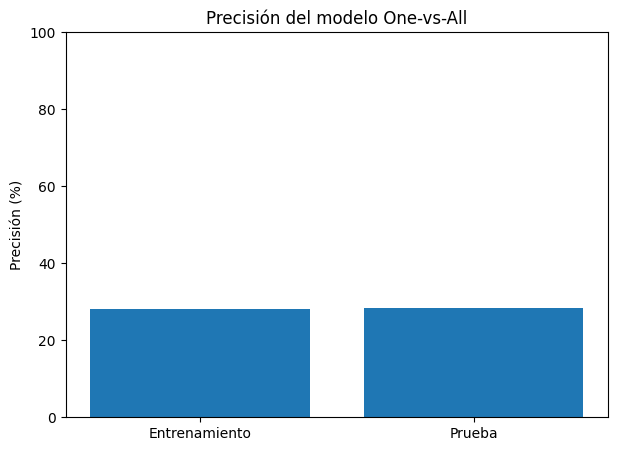

In [75]:
modelos = ["Entrenamiento", "Prueba"]
precisiones = [
    precision_entrenamiento,
    precision_prueba
]

plt.figure(figsize=(7, 5))
plt.bar(modelos, precisiones)

plt.ylabel("Precisión (%)")
plt.title("Precisión del modelo One-vs-All")
plt.ylim(0, 100)

plt.show()